# Projet : Prédiction du Genre des Films avec Naive Bayes

## Contexte
Dans ce projet, l'objectif est de prédire le genre d'un film en fonction de ses caractéristiques numériques :
- **Votes** : Le nombre de votes que le film a reçus
- **Popularité** : Un score représentant la popularité du film
- **Rating** : La note moyenne du film

Nous utiliserons un modèle de **Naive Bayes** pour effectuer cette classification multi-classes.

### Étapes du projet :
1. Téléchargement et chargement des données IMDb
2. Préparation et nettoyage des données
3. Exploration des données (EDA)
4. Séparation en ensembles d'entraînement et de test
5. Entraînement du modèle Naive Bayes
6. Évaluation des performances
7. Analyse des résultats

## 1. Import des bibliothèques

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Configuration des graphiques
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

## 2. Chargement des données

Nous allons créer un jeu de données simulé basé sur les caractéristiques typiques des films IMDb.
Dans un cas réel, vous téléchargeriez le dataset depuis [Kaggle - IMDB Movies Dataset](https://www.kaggle.com/datasets/ashirwadsangwan/imdb-dataset).

**Note:** Si vous avez le vrai dataset, remplacez la cellule suivante par:
```python
df = pd.read_csv('chemin/vers/imdb_movies.csv')
```

In [2]:
# Chargement du dataset Kaggle (user-friendly)
import importlib.util
import os
import subprocess
import sys

if importlib.util.find_spec("kagglehub") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "kagglehub"])

import kagglehub
import pandas as pd

dataset_path = kagglehub.dataset_download("jacopoferretti/idmb-movies-user-friendly")
csv_path = os.path.join(dataset_path, "MOVIES.csv")

df_kaggle = pd.read_csv(csv_path)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 0)

print(f"Chemin du dataset: {csv_path}")
print(f"Shape: {df_kaggle.shape}")
print("Colonnes:")
print(list(df_kaggle.columns))

df_kaggle.head(10)

Chemin du dataset: /Users/robinqueriaux/.cache/kagglehub/datasets/jacopoferretti/idmb-movies-user-friendly/versions/1/MOVIES.csv
Shape: (44985, 23)
Colonnes:
['adult', 'belongs_to_collection', 'budget', 'original_language', 'original_title', 'overview', 'popularity', 'release_date', 'revenue', 'runtime', 'tagline', 'title', 'vote_average', 'vote_count', 'languages', 'day_of_week', 'month', 'season', 'year', 'has_homepage', 'genre', 'companies', 'countries']


,adult,belongs_to_collection,budget,original_language,original_title,overview,popularity,release_date,revenue,runtime,tagline,title,vote_average,vote_count,languages,day_of_week,month,season,year,has_homepage,genre,companies,countries
0,False,Toy Story Collection,30000000,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",21.946943,1995-10-30,373554033.0,81.0,not available,Toy Story,7.7,5415.0,['English'],Monday,Oct,Q4,1995,YES,"['Animation', 'Comedy', 'Family']",['Pixar Animation Studios'],['United States of America']
1,False,not available,65000000,en,Jumanji,When siblings Judy and Peter discover an encha...,17.015539,1995-12-15,262797249.0,104.0,Roll the dice and unleash the excitement!,Jumanji,6.9,2413.0,"['English', 'Français']",Friday,Dec,Q4,1995,NO,"['Adventure', 'Fantasy', 'Family']","['TriStar Pictures', 'Teitler Film', 'Intersco...",['United States of America']
2,False,Grumpy Old Men Collection,0,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,11.712900,1995-12-22,0.0,101.0,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,6.5,92.0,['English'],Friday,Dec,Q4,1995,NO,"['Romance', 'Comedy']","['Warner Bros.', 'Lancaster Gate']",['United States of America']
3,False,not available,16000000,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",3.859495,1995-12-22,81452156.0,127.0,Friends are the people who let you be yourself...,Waiting to Exhale,6.1,34.0,['English'],Friday,Dec,Q4,1995,NO,"['Comedy', 'Drama', 'Romance']",['Twentieth Century Fox Film Corporation'],['United States of America']
4,False,Father of the Bride Collection,0,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,8.387519,1995-02-10,76578911.0,106.0,Just When His World Is Back To Normal... He's ...,Father of the Bride Part II,5.7,173.0,['English'],Friday,Feb,Q1,1995,NO,['Comedy'],"['Sandollar Productions', 'Touchstone Pictures']",['United States of America']
5,False,not available,60000000,en,Heat,"Obsessive master thief, Neil McCauley leads a ...",17.924927,1995-12-15,187436818.0,170.0,A Los Angeles Crime Saga,Heat,7.7,1886.0,"['English', 'Español']",Friday,Dec,Q4,1995,NO,"['Action', 'Crime', 'Drama', 'Thriller']","['Regency Enterprises', 'Forward Pass', 'Warne...",['United States of America']
6,False,not available,58000000,en,Sabrina,An ugly duckling having undergone a remarkable...,6.677277,1995-12-15,0.0,127.0,You are cordially invited to the most surprisi...,Sabrina,6.2,141.0,"['Français', 'English']",Friday,Dec,Q4,1995,NO,"['Comedy', 'Romance']","['Paramount Pictures', 'Scott Rudin Production...","['Germany', 'United States of America']"
7,False,not available,0,en,Tom and Huck,"A mischievous young boy, Tom Sawyer, witnesses...",2.561161,1995-12-22,0.0,97.0,The Original Bad Boys.,Tom and Huck,5.4,45.0,"['English', 'Deutsch']",Friday,Dec,Q4,1995,NO,"['Action', 'Adventure', 'Drama', 'Family']",['Walt Disney Pictures'],['United States of America']
8,False,not available,35000000,en,Sudden Death,International action superstar Jean Claude Van...,5.231580,1995-12-22,64350171.0,106.0,Terror goes into overtime.,Sudden Death,5.5,174.0,['English'],Friday,Dec,Q4,1995,NO,"['Action', 'Adventure', 'Thriller']","['Universal Pictures', 'Imperial Entertainment...",['United States of America']
9,False,James Bond Collection,58000000,en,GoldenEye,James Bond must unmask the mysterious head of ...,14.686036,1995-11-16,352194034.0,130.0,No limits. No fears. No substitutes.,GoldenEye,6.6,1194.0,"['English', 'Pусский', 'Español']",Thursday,Nov,Q4,1995,YES,"['Adventure', 'Action', 'Thriller']","['United Artists', 'Eon Productions']","['United Kingdom', 'United States of America']"


In [3]:
# Simplifier les colonnes en gardant le premier element des listes
import ast
import json

def first_item(value):
    if value is None or (isinstance(value, float) and pd.isna(value)):
        return None
    if isinstance(value, list):
        return value[0] if value else None
    if isinstance(value, str):
        text = value.strip()
        if not text or text.lower() in {"not available", "nan"}:
            return None
        if text.startswith("[") and text.endswith("]"):
            for parser in (ast.literal_eval, json.loads):
                try:
                    parsed = parser(text)
                    if isinstance(parsed, list):
                        return parsed[0] if parsed else None
                except Exception:
                    continue
        return text
    return value

df_kaggle_clean = df_kaggle.copy()
list_cols = ["languages", "companies", "countries", "genre", "belongs_to_collection"]
for col in list_cols:
    if col in df_kaggle_clean.columns:
        df_kaggle_clean[col] = df_kaggle_clean[col].apply(first_item)

print("=" * 60)
print("DATASET SIMPLIFIÉ")
print("=" * 60)
print(f"Shape: {df_kaggle_clean.shape}")
print(f"\nColonnes simplifiées: {list_cols}")
print(f"\nAperçu des valeurs None par colonne:")
for col in list_cols:
    if col in df_kaggle_clean.columns:
        none_count = df_kaggle_clean[col].isna().sum()
        none_pct = (none_count / len(df_kaggle_clean)) * 100
        print(f"  {col}: {none_count} ({none_pct:.1f}%)")

print(f"\n{'='*60}")
print("AFFICHAGE COMPLET DU DATASET (toutes les colonnes)")
print("=" * 60)
df_kaggle_clean.head(20)

DATASET SIMPLIFIÉ
Shape: (44985, 23)

Colonnes simplifiées: ['languages', 'companies', 'countries', 'genre', 'belongs_to_collection']

Aperçu des valeurs None par colonne:
  languages: 3754 (8.3%)
  companies: 11628 (25.8%)
  countries: 6146 (13.7%)
  genre: 2384 (5.3%)
  belongs_to_collection: 40522 (90.1%)

AFFICHAGE COMPLET DU DATASET (toutes les colonnes)


,adult,belongs_to_collection,budget,original_language,original_title,overview,popularity,release_date,revenue,runtime,tagline,title,vote_average,vote_count,languages,day_of_week,month,season,year,has_homepage,genre,companies,countries
0,False,Toy Story Collection,30000000,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",21.946943,1995-10-30,373554033.0,81.0,not available,Toy Story,7.7,5415.0,English,Monday,Oct,Q4,1995,YES,Animation,Pixar Animation Studios,United States of America
1,False,None,65000000,en,Jumanji,When siblings Judy and Peter discover an encha...,17.015539,1995-12-15,262797249.0,104.0,Roll the dice and unleash the excitement!,Jumanji,6.9,2413.0,English,Friday,Dec,Q4,1995,NO,Adventure,TriStar Pictures,United States of America
2,False,Grumpy Old Men Collection,0,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,11.712900,1995-12-22,0.0,101.0,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,6.5,92.0,English,Friday,Dec,Q4,1995,NO,Romance,Warner Bros.,United States of America
3,False,None,16000000,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",3.859495,1995-12-22,81452156.0,127.0,Friends are the people who let you be yourself...,Waiting to Exhale,6.1,34.0,English,Friday,Dec,Q4,1995,NO,Comedy,Twentieth Century Fox Film Corporation,United States of America
4,False,Father of the Bride Collection,0,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,8.387519,1995-02-10,76578911.0,106.0,Just When His World Is Back To Normal... He's ...,Father of the Bride Part II,5.7,173.0,English,Friday,Feb,Q1,1995,NO,Comedy,Sandollar Productions,United States of America
5,False,None,60000000,en,Heat,"Obsessive master thief, Neil McCauley leads a ...",17.924927,1995-12-15,187436818.0,170.0,A Los Angeles Crime Saga,Heat,7.7,1886.0,English,Friday,Dec,Q4,1995,NO,Action,Regency Enterprises,United States of America
6,False,None,58000000,en,Sabrina,An ugly duckling having undergone a remarkable...,6.677277,1995-12-15,0.0,127.0,You are cordially invited to the most surprisi...,Sabrina,6.2,141.0,Français,Friday,Dec,Q4,1995,NO,Comedy,Paramount Pictures,Germany
7,False,None,0,en,Tom and Huck,"A mischievous young boy, Tom Sawyer, witnesses...",2.561161,1995-12-22,0.0,97.0,The Original Bad Boys.,Tom and Huck,5.4,45.0,English,Friday,Dec,Q4,1995,NO,Action,Walt Disney Pictures,United States of America
8,False,None,35000000,en,Sudden Death,International action superstar Jean Claude Van...,5.231580,1995-12-22,64350171.0,106.0,Terror goes into overtime.,Sudden Death,5.5,174.0,English,Friday,Dec,Q4,1995,NO,Action,Universal Pictures,United States of America
9,False,James Bond Collection,58000000,en,GoldenEye,James Bond must unmask the mysterious head of ...,14.686036,1995-11-16,352194034.0,130.0,No limits. No fears. No substitutes.,GoldenEye,6.6,1194.0,English,Thursday,Nov,Q4,1995,YES,Adventure,United Artists,United Kingdom


## 3. Analyse du dataset et nettoyage

In [4]:
# Analyse du dataset
print(f"Shape: {df_kaggle_clean.shape}\n")

# Valeurs manquantes
missing = df_kaggle_clean.isnull().sum()[df_kaggle_clean.isnull().sum() > 0]
print("Valeurs manquantes:")
for col, count in missing.items():
    pct = count / len(df_kaggle_clean) * 100
    print(f"  {col}: {count} ({pct:.1f}%)")

# Distribution des genres
print(f"\nGenres: {df_kaggle_clean['genre'].nunique()} uniques")
print(df_kaggle_clean['genre'].value_counts().head(10))

Shape: (44985, 23)

Valeurs manquantes:
  belongs_to_collection: 40522 (90.1%)
  languages: 3754 (8.3%)
  genre: 2384 (5.3%)
  companies: 11628 (25.8%)
  countries: 6146 (13.7%)

Genres: 20 uniques
genre
Drama          11836
Comedy          8742
Action          4456
Documentary     3360
Horror          2601
Crime           1676
Thriller        1646
Adventure       1499
Romance         1178
Animation       1113
Name: count, dtype: int64


## 4. Nettoyage des données

In [5]:
# Nettoyage du dataset
df_clean = df_kaggle_clean.copy()
print(f"Dataset initial: {df_clean.shape}")

# Supprimer les lignes sans genre  
df_clean = df_clean.dropna(subset=['genre'])
print(f"Après suppression genre manquant: {df_clean.shape}")

# Sélection des features
features_to_keep = [
    'vote_count', 'vote_average', 'popularity', 'runtime', 
    'year', 'month', 'season', 'day_of_week',
    'has_homepage', 'original_language', 'genre'
]
df_clean = df_clean[features_to_keep]

# Traitement valeurs manquantes
df_clean['runtime'] = df_clean.groupby('genre')['runtime'].transform(
    lambda x: x.fillna(x.median())
)
if df_clean['runtime'].isna().sum() > 0:
    df_clean['runtime'].fillna(df_clean['runtime'].median(), inplace=True)
    
df_clean['has_homepage'].fillna(False, inplace=True)

# Regrouper langues (top-10 + Other)
top_10_languages = df_clean['original_language'].value_counts().head(10).index.tolist()
print(f"   Top 10 langues: {top_10_languages}")
df_clean['original_language'] = df_clean['original_language'].apply(
    lambda x: x if x in top_10_languages else 'Other'
)
print(f"   → Langues uniques après regroupement: {df_clean['original_language'].nunique()}")

# ÉTAPE 6: Vérification finale
print("\n" + "="*80)
print("DATASET NETTOYÉ - RÉSUMÉ")
print("="*80)
print(f"\n📊 Taille finale: {len(df_clean):,} films × {len(df_clean.columns)} colonnes")
print(f"\n📋 Colonnes finales:")
for i, col in enumerate(df_clean.columns, 1):
    dtype = df_clean[col].dtype
    missing = df_clean[col].isna().sum()
    unique = df_clean[col].nunique() if dtype == 'object' or dtype == 'bool' else 'N/A'
    print(f"   {i:2}. {col:20} | Type: {str(dtype):10} | Missing: {missing:5} | Unique: {unique}")

print(f"\n✅ Dataset prêt pour l'entraînement!")
print("="*80)

Dataset initial: (44985, 23)
Après suppression genre manquant: (42601, 23)
   Top 10 langues: ['en', 'fr', 'it', 'ja', 'de', 'es', 'ru', 'hi', 'ko', 'zh']
   → Langues uniques après regroupement: 11

DATASET NETTOYÉ - RÉSUMÉ

📊 Taille finale: 42,601 films × 11 colonnes

📋 Colonnes finales:
    1. vote_count           | Type: float64    | Missing:     0 | Unique: N/A
    2. vote_average         | Type: float64    | Missing:     0 | Unique: N/A
    3. popularity           | Type: float64    | Missing:     0 | Unique: N/A
    4. runtime              | Type: float64    | Missing:     0 | Unique: N/A
    5. year                 | Type: int64      | Missing:     0 | Unique: N/A
    6. month                | Type: object     | Missing:     0 | Unique: 13
    7. season               | Type: object     | Missing:     0 | Unique: 5
    8. day_of_week          | Type: object     | Missing:     0 | Unique: 8
    9. has_homepage         | Type: object     | Missing:     0 | Unique: 2
   10. origina

## 5. Vue du dataset nettoyé

In [6]:
# Affichage du dataset
print(f"Dataset: {len(df_clean):,} lignes × {len(df_clean.columns)} colonnes\n")

# Info colonnes
print("Colonnes:")
for i, col in enumerate(df_clean.columns, 1):
    dtype = df_clean[col].dtype
    unique = df_clean[col].nunique() if dtype in ['object', 'bool'] else '-'
    print(f"  {i:2}. {col:20} | {str(dtype):10} | Unique: {unique}")

print("\n" + "="*80)
df_clean

Dataset: 42,601 lignes × 11 colonnes

Colonnes:
   1. vote_count           | float64    | Unique: -
   2. vote_average         | float64    | Unique: -
   3. popularity           | float64    | Unique: -
   4. runtime              | float64    | Unique: -
   5. year                 | int64      | Unique: -
   6. month                | object     | Unique: 13
   7. season               | object     | Unique: 5
   8. day_of_week          | object     | Unique: 8
   9. has_homepage         | object     | Unique: 2
  10. original_language    | object     | Unique: 11
  11. genre                | object     | Unique: 20



,vote_count,vote_average,popularity,runtime,year,month,season,day_of_week,has_homepage,original_language,genre
0,5415.0,7.7,21.946943,81.0,1995,Oct,Q4,Monday,YES,en,Animation
1,2413.0,6.9,17.015539,104.0,1995,Dec,Q4,Friday,NO,en,Adventure
2,92.0,6.5,11.712900,101.0,1995,Dec,Q4,Friday,NO,en,Romance
3,34.0,6.1,3.859495,127.0,1995,Dec,Q4,Friday,NO,en,Comedy
4,173.0,5.7,8.387519,106.0,1995,Feb,Q1,Friday,NO,en,Comedy
...,...,...,...,...,...,...,...,...,...,...,...
44978,1.0,3.5,0.661558,85.0,1995,Jan,Q1,Sunday,NO,en,Science Fiction
44979,26.0,5.7,5.683753,104.0,1991,May,Q2,Monday,NO,en,Drama
44980,1.0,4.0,0.072051,90.0,0,not available,not available,not available,YES,Other,Drama
44981,3.0,9.0,0.178241,360.0,2011,Nov,Q4,Thursday,NO,Other,Drama


## 6. Préparation des données pour l'entraînement

In [7]:
# Encodage des variables catégorielles
df_encoded = df_clean.copy()

# Encoder la cible (genre)
le_genre = LabelEncoder()
df_encoded['genre_encoded'] = le_genre.fit_transform(df_encoded['genre'])

print("Encodage de la cible (genre):")
for i, genre in enumerate(le_genre.classes_):
    print(f"  {genre}: {i}")

# Encoder original_language
le_lang = LabelEncoder()
df_encoded['language_encoded'] = le_lang.fit_transform(df_encoded['original_language'])

print(f"\nEncodage original_language:")
for i, lang in enumerate(le_lang.classes_):
    print(f"  {lang}: {i}")

# Encoder les autres colonnes catégorielles (month, season, day_of_week, has_homepage)
le_month = LabelEncoder()
df_encoded['month_encoded'] = le_month.fit_transform(df_encoded['month'])

le_season = LabelEncoder()
df_encoded['season_encoded'] = le_season.fit_transform(df_encoded['season'])

le_day = LabelEncoder()
df_encoded['day_encoded'] = le_day.fit_transform(df_encoded['day_of_week'])

le_homepage = LabelEncoder()
df_encoded['homepage_encoded'] = le_homepage.fit_transform(df_encoded['has_homepage'].astype(str))

print(f"\nDataset après encodage: {df_encoded.shape}")

Encodage de la cible (genre):
  Action: 0
  Adventure: 1
  Animation: 2
  Comedy: 3
  Crime: 4
  Documentary: 5
  Drama: 6
  Family: 7
  Fantasy: 8
  Foreign: 9
  History: 10
  Horror: 11
  Music: 12
  Mystery: 13
  Romance: 14
  Science Fiction: 15
  TV Movie: 16
  Thriller: 17
  War: 18
  Western: 19

Encodage original_language:
  Other: 0
  de: 1
  en: 2
  es: 3
  fr: 4
  hi: 5
  it: 6
  ja: 7
  ko: 8
  ru: 9
  zh: 10

Dataset après encodage: (42601, 17)


In [8]:
# Définir les features (X) et la cible (y)
feature_cols = ['vote_count', 'vote_average', 'popularity', 'runtime', 'year',
                'month_encoded', 'season_encoded', 'day_encoded', 'homepage_encoded', 'language_encoded']

X = df_encoded[feature_cols].values
y = df_encoded['genre_encoded'].values

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

# Normalisation des features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"\nFeatures normalisées:")
print(f"  Moyenne: {X_scaled.mean(axis=0)}")

X shape: (42601, 10)
y shape: (42601,)

Features normalisées:
  Moyenne: [ 2.13491397e-17 -3.73609945e-16  0.00000000e+00  4.26982795e-17
  2.18828682e-16  1.05411377e-16 -2.66864247e-17  4.53669219e-17
  5.33728493e-18  1.12082984e-16]


## 7. Séparation train/test

In [9]:
# Split train/test (80/20) avec stratification
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train set: {len(X_train)} échantillons ({len(X_train)/len(X_scaled)*100:.1f}%)")
print(f"Test set:  {len(X_test)} échantillons ({len(X_test)/len(X_scaled)*100:.1f}%)")

print(f"\nDistribution des genres (train set):")
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique[:5], counts[:5]):
    print(f"  {le_genre.classes_[u]}: {c} ({c/len(y_train)*100:.1f}%)")

Train set: 34080 échantillons (80.0%)
Test set:  8521 échantillons (20.0%)

Distribution des genres (train set):
  Action: 3565 (10.5%)
  Adventure: 1199 (3.5%)
  Animation: 890 (2.6%)
  Comedy: 6993 (20.5%)
  Crime: 1341 (3.9%)


## 5. Modèle Naive Bayes

In [10]:
from sklearn.naive_bayes import GaussianNB

# Entraînement
model = GaussianNB()
model.fit(X_train, y_train)

# Prédictions
y_pred = model.predict(X_test)

print(f"Entraînement terminé sur {len(X_train)} films")
print(f"Prédictions générées sur {len(X_test)} films")

Entraînement terminé sur 34080 films
Prédictions générées sur 8521 films


## 6. Évaluation

In [11]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Score global
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.3f}")
print(f"\nRapport de classification:\n")
print(classification_report(y_test, y_pred, target_names=le_genre.classes_))

Accuracy: 0.152

Rapport de classification:

                 precision    recall  f1-score   support

         Action       0.16      0.05      0.08       891
      Adventure       0.15      0.08      0.11       300
      Animation       0.67      0.03      0.05       223
         Comedy       0.24      0.28      0.26      1749
          Crime       0.00      0.00      0.00       335
    Documentary       0.17      0.60      0.26       672
          Drama       0.38      0.11      0.17      2368
         Family       0.00      0.00      0.00       103
        Fantasy       0.00      0.00      0.00       140
        Foreign       0.01      0.78      0.02        23
        History       0.08      0.04      0.05        55
         Horror       0.14      0.07      0.10       520
          Music       0.00      0.00      0.00        97
        Mystery       0.00      0.00      0.00       110
        Romance       0.00      0.00      0.00       236
Science Fiction       0.00      0.00      

In [12]:
# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
print("Matrice de confusion (10 premiers genres):")
print(cm[:10, :10])

Matrice de confusion (10 premiers genres):
[[ 48  41   1 232   0 141 101   0   0 233]
 [ 27  24   0  67   0  67  35   0   0  49]
 [ 14   6   6  44   0  60  23   0   0  48]
 [ 63  14   1 488   0 485  97   0   0 445]
 [ 15   6   0  91   0 116  32   0   0  60]
 [  0   0   0  52   0 401  11   0   0 188]
 [ 55  32   0 564   0 612 260   0   0 744]
 [  2   4   1  27   0  23   2   0   0  35]
 [ 10   4   0  40   0  34  12   0   0  23]
 [  0   0   0   1   0   3   1   0   0  18]]


## 7. Visualisations

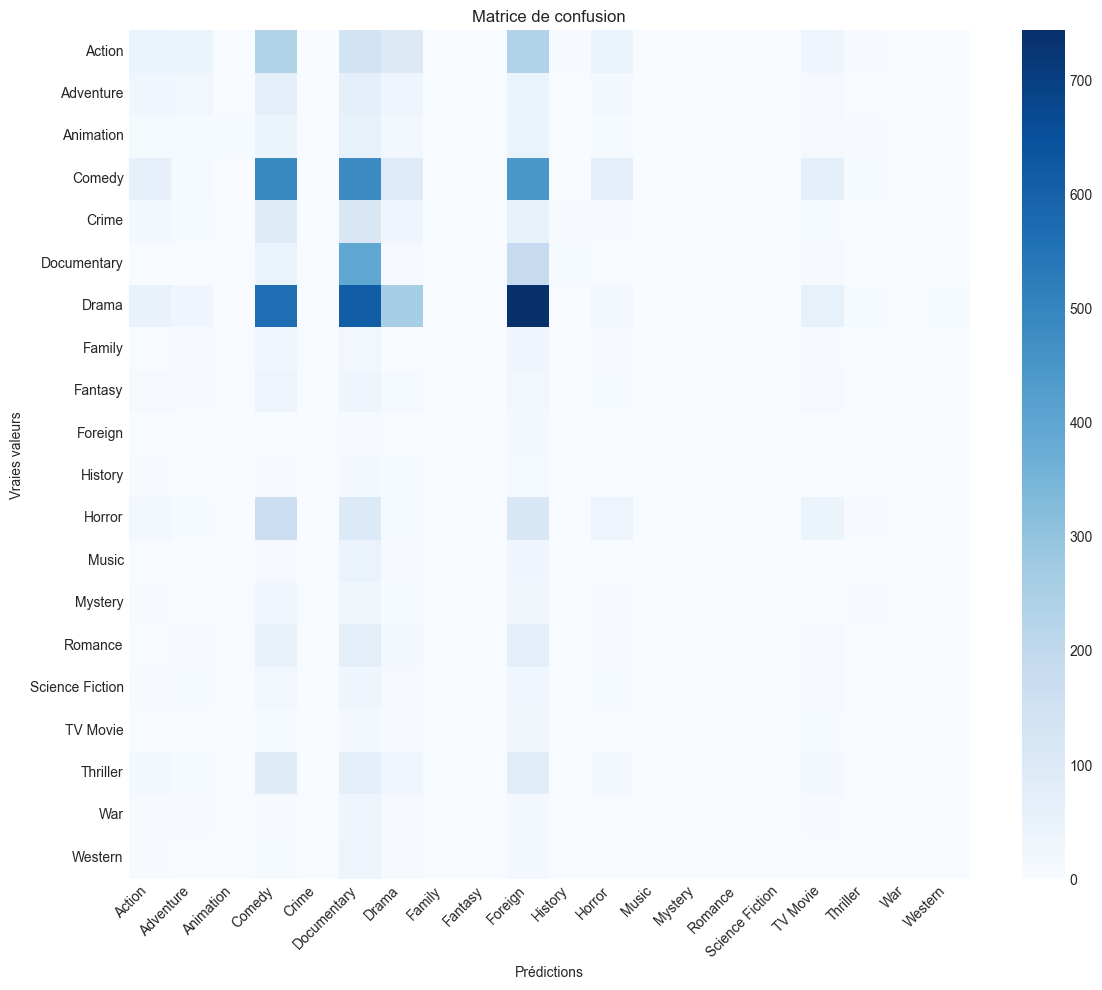

In [13]:
# Heatmap matrice de confusion
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=False, cmap='Blues', 
            xticklabels=le_genre.classes_, 
            yticklabels=le_genre.classes_)
plt.xlabel('Prédictions')
plt.ylabel('Vraies valeurs')
plt.title('Matrice de confusion')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

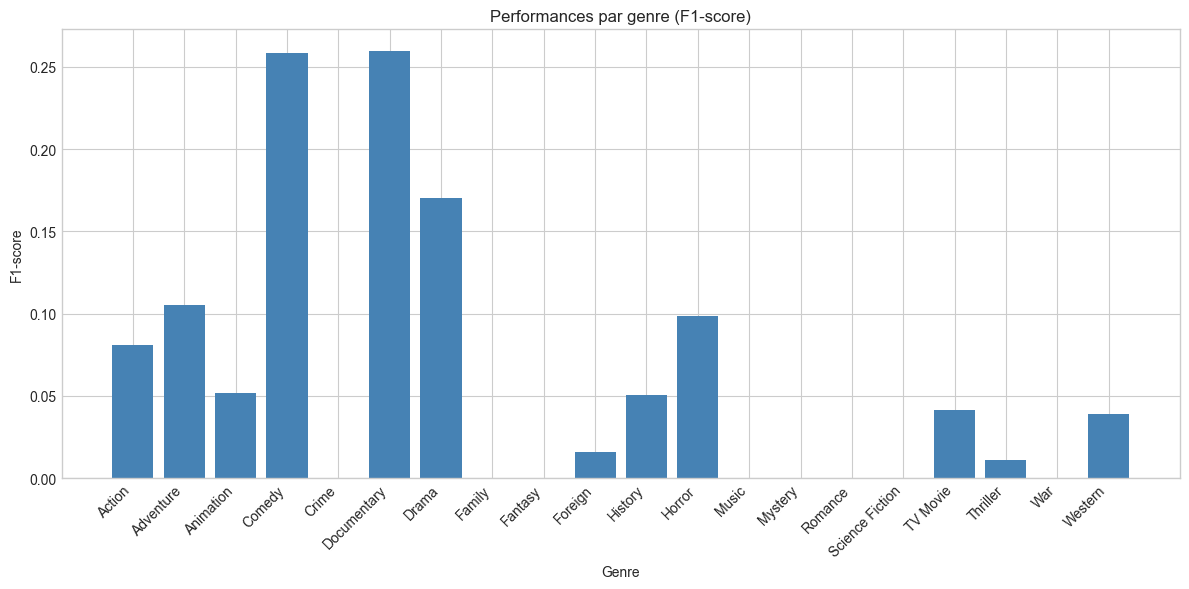

In [14]:
# Performances par genre
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, support = precision_recall_fscore_support(y_test, y_pred, labels=range(len(le_genre.classes_)))

# Graphique des F1-scores par genre
plt.figure(figsize=(12, 6))
plt.bar(range(len(le_genre.classes_)), f1, color='steelblue')
plt.xlabel('Genre')
plt.ylabel('F1-score')
plt.title('Performances par genre (F1-score)')
plt.xticks(range(len(le_genre.classes_)), le_genre.classes_, rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 8. Amélioration du modèle - Feature Engineering avancé

In [15]:
# Extraction de TOUS les genres (pas juste le premier)
def extract_all_items(value):
    """Extrait tous les éléments d'une liste encodée en string"""
    if value is None or (isinstance(value, float) and pd.isna(value)):
        return []
    if isinstance(value, list):
        return value
    if isinstance(value, str):
        text = value.strip()
        if not text or text.lower() in {"not available", "nan"}:
            return []
        if text.startswith("[") and text.endswith("]"):
            for parser in (ast.literal_eval, json.loads):
                try:
                    parsed = parser(text)
                    if isinstance(parsed, list):
                        return parsed
                except Exception:
                    continue
        return [text]
    return []

# Recharger dataset original et extraire toutes les listes
df_multihot = df_kaggle.copy()

# Extraire tous les genres, companies, countries
df_multihot['all_genres'] = df_multihot['genre'].apply(extract_all_items)
df_multihot['all_companies'] = df_multihot['companies'].apply(extract_all_items)
df_multihot['all_countries'] = df_multihot['countries'].apply(extract_all_items)

# Garder le premier genre comme cible
df_multihot['genre_target'] = df_multihot['all_genres'].apply(lambda x: x[0] if x else None)

# Filtrer
df_multihot = df_multihot.dropna(subset=['genre_target'])
df_multihot = df_multihot[df_multihot['vote_count'] >= 50]  # Filtrer le bruit

print(f"Dataset après filtrage (vote_count >= 50): {len(df_multihot):,} films")
print(f"Films retirés (bruit): {len(df_kaggle) - len(df_multihot):,}")
print(f"\nGenres uniques: {df_multihot['genre_target'].nunique()}")

Dataset après filtrage (vote_count >= 50): 9,125 films
Films retirés (bruit): 35,860

Genres uniques: 19


In [16]:
# Multi-hot encoding pour genres secondaires
from sklearn.preprocessing import MultiLabelBinarizer

# Top 20 genres pour features binaires (sauf le genre cible qu'on prédit)
all_genres_flat = [g for genres in df_multihot['all_genres'] for g in genres]
top_genres = pd.Series(all_genres_flat).value_counts().head(20).index.tolist()

mlb_genres = MultiLabelBinarizer(classes=top_genres)
genre_features = mlb_genres.fit_transform(df_multihot['all_genres'])
genre_df = pd.DataFrame(genre_features, columns=[f'has_{g}' for g in top_genres], index=df_multihot.index)

print(f"Features genre créées: {genre_df.shape[1]} colonnes")
print(f"Top genres: {top_genres[:10]}")

# Top 30 companies
all_companies_flat = [c for companies in df_multihot['all_companies'] for c in companies if c]
top_companies = pd.Series(all_companies_flat).value_counts().head(30).index.tolist()

mlb_companies = MultiLabelBinarizer(classes=top_companies)
company_features = mlb_companies.fit_transform(df_multihot['all_companies'])
company_df = pd.DataFrame(company_features, columns=[f'company_{i}' for i in range(len(top_companies))], index=df_multihot.index)

print(f"\nFeatures company créées: {company_df.shape[1]} colonnes")
print(f"Top companies: {top_companies[:5]}")

# Top 20 countries
all_countries_flat = [c for countries in df_multihot['all_countries'] for c in countries if c]
top_countries = pd.Series(all_countries_flat).value_counts().head(20).index.tolist()

mlb_countries = MultiLabelBinarizer(classes=top_countries)
country_features = mlb_countries.fit_transform(df_multihot['all_countries'])
country_df = pd.DataFrame(country_features, columns=[f'country_{i}' for i in range(len(top_countries))], index=df_multihot.index)

print(f"\nFeatures country créées: {country_df.shape[1]} colonnes")
print(f"Top countries: {top_countries[:5]}")

# Collection (binaire)
df_multihot['has_collection'] = df_multihot['belongs_to_collection'].notna().astype(int)
print(f"\nFilms dans une collection: {df_multihot['has_collection'].sum()} ({df_multihot['has_collection'].mean()*100:.1f}%)")

Features genre créées: 20 colonnes
Top genres: ['Drama', 'Comedy', 'Thriller', 'Action', 'Romance', 'Adventure', 'Crime', 'Horror', 'Science Fiction', 'Family']

Features company créées: 30 colonnes
Top companies: ['Warner Bros.', 'Universal Pictures', 'Paramount Pictures', 'Twentieth Century Fox Film Corporation', 'Columbia Pictures']

Features country créées: 20 colonnes
Top countries: ['United States of America', 'United Kingdom', 'France', 'Germany', 'Canada']

Films dans une collection: 9125 (100.0%)


In [17]:
# Préparer dataset complet avec toutes les features
df_improved = pd.concat([
    df_multihot[['vote_count', 'vote_average', 'popularity', 'runtime', 
                 'year', 'month', 'season', 'day_of_week', 'has_homepage', 
                 'original_language', 'genre_target', 'has_collection']].reset_index(drop=True),
    genre_df.reset_index(drop=True),
    company_df.reset_index(drop=True),
    country_df.reset_index(drop=True)
], axis=1)

# Nettoyer
df_improved = df_improved.dropna(subset=['genre_target', 'runtime'])
df_improved['runtime'] = df_improved.groupby('genre_target')['runtime'].transform(lambda x: x.fillna(x.median()))
df_improved['has_homepage'].fillna(False, inplace=True)

# Regrouper langues
top_langs = df_improved['original_language'].value_counts().head(10).index.tolist()
df_improved['original_language'] = df_improved['original_language'].apply(lambda x: x if x in top_langs else 'Other')

print(f"Dataset amélioré: {df_improved.shape}")
print(f"\nColonnes: {df_improved.shape[1]} (vs 11 dans version de base)")
print(f"Exemples films avec multi-genres:")
sample = df_multihot[df_multihot['all_genres'].apply(len) > 1].head(3)
for idx, row in sample.iterrows():
    print(f"  - {row['all_genres'][:3]} → cible: {row['genre_target']}")

Dataset amélioré: (9125, 82)

Colonnes: 82 (vs 11 dans version de base)
Exemples films avec multi-genres:
  - ['Animation', 'Comedy', 'Family'] → cible: Animation
  - ['Adventure', 'Fantasy', 'Family'] → cible: Adventure
  - ['Romance', 'Comedy'] → cible: Romance


In [18]:
# Encodage pour le modèle amélioré
df_improved_enc = df_improved.copy()

# Encoder la cible
le_genre_v2 = LabelEncoder()
y_improved = le_genre_v2.fit_transform(df_improved_enc['genre_target'])

# Encoder catégorielles
le_lang_v2 = LabelEncoder()
df_improved_enc['lang_enc'] = le_lang_v2.fit_transform(df_improved_enc['original_language'])

le_month_v2 = LabelEncoder()
df_improved_enc['month_enc'] = le_month_v2.fit_transform(df_improved_enc['month'])

le_season_v2 = LabelEncoder()
df_improved_enc['season_enc'] = le_season_v2.fit_transform(df_improved_enc['season'])

le_day_v2 = LabelEncoder()
df_improved_enc['day_enc'] = le_day_v2.fit_transform(df_improved_enc['day_of_week'])

# Encoder has_homepage (peut être YES/NO ou True/False)
le_homepage_v2 = LabelEncoder()
df_improved_enc['homepage_enc'] = le_homepage_v2.fit_transform(df_improved_enc['has_homepage'].astype(str))

# Sélectionner features
numeric_features = ['vote_count', 'vote_average', 'popularity', 'runtime', 'year']
encoded_features = ['lang_enc', 'month_enc', 'season_enc', 'day_enc', 'homepage_enc', 'has_collection']
# Exclure has_homepage (version string) des genre_features
genre_features = [col for col in df_improved_enc.columns if col.startswith('has_') and col != 'has_homepage']
company_features = [col for col in df_improved_enc.columns if col.startswith('company_')]
country_features = [col for col in df_improved_enc.columns if col.startswith('country_')]

all_features = numeric_features + encoded_features + genre_features + company_features + country_features
X_improved = df_improved_enc[all_features].values

print(f"X shape: {X_improved.shape}")
print(f"y shape: {y_improved.shape}")
print(f"\nBreakdown features:")
print(f"  Numériques: {len(numeric_features)}")
print(f"  Encodées: {len(encoded_features)}")
print(f"  Genres (multi-hot): {len(genre_features)}")
print(f"  Companies (multi-hot): {len(company_features)}")
print(f"  Countries (multi-hot): {len(country_features)}")
print(f"  TOTAL: {len(all_features)}")

X shape: (9125, 82)
y shape: (9125,)

Breakdown features:
  Numériques: 5
  Encodées: 6
  Genres (multi-hot): 21
  Companies (multi-hot): 30
  Countries (multi-hot): 20
  TOTAL: 82


In [19]:
# Split train/test
X_train_v2, X_test_v2, y_train_v2, y_test_v2 = train_test_split(
    X_improved, y_improved, test_size=0.2, random_state=42, stratify=y_improved
)

print(f"Train: {len(X_train_v2):,} films")
print(f"Test: {len(X_test_v2):,} films")

Train: 7,300 films
Test: 1,825 films


## 9. Test de différentes variantes Naive Bayes

In [20]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB, ComplementNB
from sklearn.preprocessing import MinMaxScaler

# Test 1: GaussianNB avec features améliorées
scaler_v2 = StandardScaler()
X_train_gaussian = scaler_v2.fit_transform(X_train_v2)
X_test_gaussian = scaler_v2.transform(X_test_v2)

model_gaussian_v2 = GaussianNB()
model_gaussian_v2.fit(X_train_gaussian, y_train_v2)
y_pred_gaussian = model_gaussian_v2.predict(X_test_gaussian)
acc_gaussian = accuracy_score(y_test_v2, y_pred_gaussian)

print(f"GaussianNB (version améliorée): {acc_gaussian:.3f}")

# Test 2: MultinomialNB (nécessite features >= 0)
scaler_minmax = MinMaxScaler()
X_train_multinomial = scaler_minmax.fit_transform(X_train_v2)
X_test_multinomial = scaler_minmax.transform(X_test_v2)

model_multinomial = MultinomialNB(alpha=0.1)
model_multinomial.fit(X_train_multinomial, y_train_v2)
y_pred_multinomial = model_multinomial.predict(X_test_multinomial)
acc_multinomial = accuracy_score(y_test_v2, y_pred_multinomial)

print(f"MultinomialNB: {acc_multinomial:.3f}")

# Test 3: ComplementNB (meilleur pour données déséquilibrées)
model_complement = ComplementNB(alpha=0.1)
model_complement.fit(X_train_multinomial, y_train_v2)
y_pred_complement = model_complement.predict(X_test_multinomial)
acc_complement = accuracy_score(y_test_v2, y_pred_complement)

print(f"ComplementNB: {acc_complement:.3f}")

print(f"\n{'='*60}")
print("COMPARAISON FINALE:")
print(f"{'='*60}")
print(f"GaussianNB baseline (10 features): 0.152")
print(f"GaussianNB amélioré ({X_improved.shape[1]} features): {acc_gaussian:.3f}")
print(f"MultinomialNB ({X_improved.shape[1]} features): {acc_multinomial:.3f}")
print(f"ComplementNB ({X_improved.shape[1]} features): {acc_complement:.3f}")
print(f"\nMeilleur modèle: {['GaussianNB', 'MultinomialNB', 'ComplementNB'][[acc_gaussian, acc_multinomial, acc_complement].index(max([acc_gaussian, acc_multinomial, acc_complement]))]}")

GaussianNB (version améliorée): 0.433
MultinomialNB: 0.665
ComplementNB: 0.699

COMPARAISON FINALE:
GaussianNB baseline (10 features): 0.152
GaussianNB amélioré (82 features): 0.433
MultinomialNB (82 features): 0.665
ComplementNB (82 features): 0.699

Meilleur modèle: ComplementNB


In [21]:
# Rapport détaillé du meilleur modèle
best_model_idx= [acc_gaussian, acc_multinomial, acc_complement].index(max([acc_gaussian, acc_multinomial, acc_complement]))
best_predictions = [y_pred_gaussian, y_pred_multinomial, y_pred_complement][best_model_idx]
best_model_name = ['GaussianNB', 'MultinomialNB', 'ComplementNB'][best_model_idx]

print(f"Rapport détaillé - {best_model_name}")
print(f"{'='*80}\n")
print(classification_report(y_test_v2, best_predictions, target_names=le_genre_v2.classes_))

Rapport détaillé - ComplementNB

                 precision    recall  f1-score   support

         Action       0.69      0.95      0.80       271
      Adventure       0.64      0.28      0.39       116
      Animation       0.57      0.96      0.72        71
         Comedy       0.77      0.94      0.84       395
          Crime       0.56      0.42      0.48        84
    Documentary       0.84      1.00      0.91        32
          Drama       0.74      0.75      0.75       434
         Family       0.00      0.00      0.00        22
        Fantasy       0.71      0.10      0.18        49
        History       0.00      0.00      0.00         8
         Horror       0.56      0.91      0.69       137
          Music       1.00      0.09      0.17        11
        Mystery       0.00      0.00      0.00        23
        Romance       0.00      0.00      0.00        37
Science Fiction       1.00      0.14      0.24        29
       TV Movie       0.00      0.00      0.00        

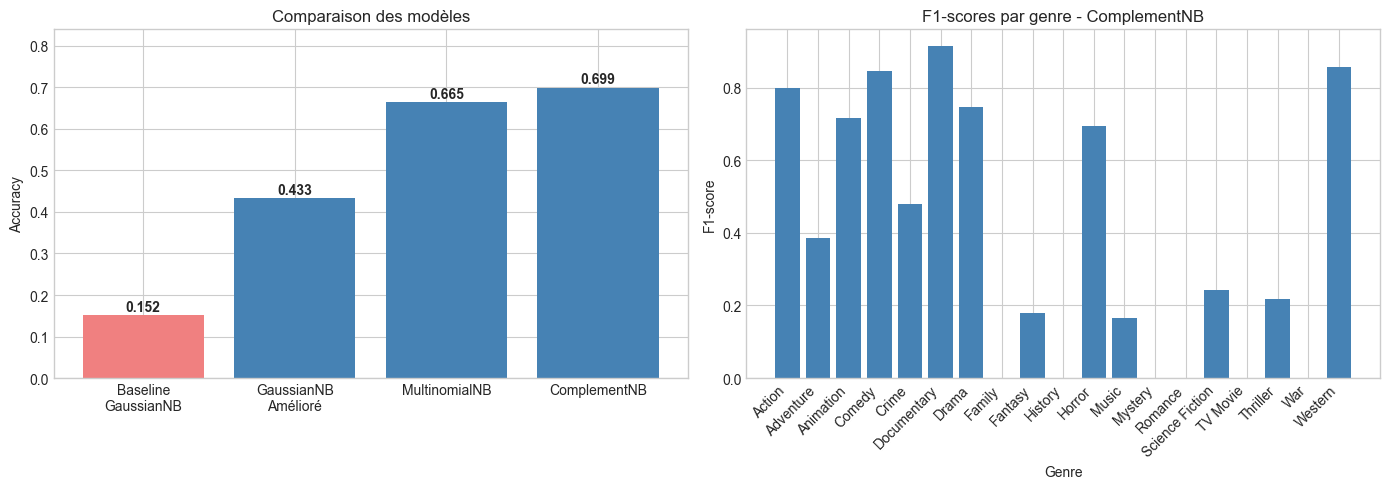


Gain d'accuracy: +0.547 (360.0% d'amélioration)


In [22]:
# Visualisation comparaison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graphique 1: Comparaison des accuracies
models = ['Baseline\nGaussianNB', 'GaussianNB\nAmélioré', 'MultinomialNB', 'ComplementNB']
accuracies = [0.152, acc_gaussian, acc_multinomial, acc_complement]
colors = ['lightcoral', 'steelblue', 'steelblue', 'steelblue']

axes[0].bar(models, accuracies, color=colors)
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Comparaison des modèles')
axes[0].set_ylim([0, max(accuracies) * 1.2])
for i, v in enumerate(accuracies):
    axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')

# Graphique 2: F1-scores par genre (meilleur modèle)
precision_v2, recall_v2, f1_v2, support_v2 = precision_recall_fscore_support(
    y_test_v2, best_predictions, labels=range(len(le_genre_v2.classes_))
)

axes[1].bar(range(len(le_genre_v2.classes_)), f1_v2, color='steelblue')
axes[1].set_xlabel('Genre')
axes[1].set_ylabel('F1-score')
axes[1].set_title(f'F1-scores par genre - {best_model_name}')
axes[1].set_xticks(range(len(le_genre_v2.classes_)))
axes[1].set_xticklabels(le_genre_v2.classes_, rotation=45, ha='right')

plt.tight_layout()
plt.show()

print(f"\nGain d'accuracy: +{max([acc_gaussian, acc_multinomial, acc_complement]) - 0.152:.3f} ({((max([acc_gaussian, acc_multinomial, acc_complement]) - 0.152) / 0.152 * 100):.1f}% d'amélioration)")

## 10. Sauvegarde des artefacts pour l'application Streamlit

In [23]:
import joblib
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix
)

# --- Identifier le meilleur modèle et ses données ---
best_model_idx = [acc_gaussian, acc_multinomial, acc_complement].index(
    max([acc_gaussian, acc_multinomial, acc_complement])
)
best_models = [model_gaussian_v2, model_multinomial, model_complement]
best_scalers = [scaler_v2, scaler_minmax, scaler_minmax]
best_model_names = ['GaussianNB', 'MultinomialNB', 'ComplementNB']
best_preds = [y_pred_gaussian, y_pred_multinomial, y_pred_complement]

best_model = best_models[best_model_idx]
best_scaler = best_scalers[best_model_idx]
best_name = best_model_names[best_model_idx]
best_y_pred = best_preds[best_model_idx]

# --- Métriques pour chaque modèle ---
all_model_metrics = {}
for name, y_pred_m, acc in zip(
    best_model_names,
    best_preds,
    [acc_gaussian, acc_multinomial, acc_complement]
):
    all_model_metrics[name] = {
        'accuracy': float(acc),
        'f1_weighted': float(f1_score(y_test_v2, y_pred_m, average='weighted')),
        'f1_macro': float(f1_score(y_test_v2, y_pred_m, average='macro')),
        'precision_weighted': float(precision_score(y_test_v2, y_pred_m, average='weighted')),
        'precision_macro': float(precision_score(y_test_v2, y_pred_m, average='macro')),
        'recall_weighted': float(recall_score(y_test_v2, y_pred_m, average='weighted')),
        'recall_macro': float(recall_score(y_test_v2, y_pred_m, average='macro')),
    }

# --- Classification reports ---
reports = {}
conf_matrices = {}
for name, y_pred_m in zip(best_model_names, best_preds):
    reports[name] = classification_report(y_test_v2, y_pred_m, target_names=le_genre_v2.classes_, output_dict=True)
    conf_matrices[name] = confusion_matrix(y_test_v2, y_pred_m).tolist()

# --- Sauvegarder tout ---
artifacts = {
    # Modèle
    'best_model': best_model,
    'best_model_name': best_name,
    'best_scaler': best_scaler,
    'label_encoder': le_genre_v2,
    # Features
    'all_features': all_features,
    'numeric_features': numeric_features,
    'encoded_features': encoded_features,
    'genre_features': genre_features,
    'company_features': company_features,
    'country_features': country_features,
    # Encodeurs catégoriels
    'le_lang': le_lang_v2,
    'le_month': le_month_v2,
    'le_season': le_season_v2,
    'le_day': le_day_v2,
    'le_homepage': le_homepage_v2,
    # Multi-hot binarizers
    'mlb_genres': mlb_genres,
    'mlb_companies': mlb_companies,
    'mlb_countries': mlb_countries,
    'top_genres': top_genres,
    'top_companies': top_companies,
    'top_countries': top_countries,
    'top_languages': top_langs,
    # Données d'évaluation
    'all_model_metrics': all_model_metrics,
    'classification_reports': reports,
    'confusion_matrices': conf_matrices,
    'y_test': y_test_v2.tolist(),
    'y_preds': {name: pred.tolist() for name, pred in zip(best_model_names, best_preds)},
    'test_size': len(y_test_v2),
    'train_size': len(y_train_v2),
    'n_classes': len(le_genre_v2.classes_),
    'n_features': len(all_features),
    # Tous les modèles (pour comparaison dans l'app)
    'all_models': {name: m for name, m in zip(best_model_names, best_models)},
    'all_scalers': {name: s for name, s in zip(best_model_names, best_scalers)},
}

joblib.dump(artifacts, 'model_artifacts.pkl')
print(f'Artefacts sauvegardés dans model_artifacts.pkl')
print(f'Meilleur modèle : {best_name} (Accuracy={all_model_metrics[best_name]["accuracy"]:.3f})')
print(f'Features : {len(all_features)}')
print(f'Classes : {list(le_genre_v2.classes_)}')

Artefacts sauvegardés dans model_artifacts.pkl
Meilleur modèle : ComplementNB (Accuracy=0.699)
Features : 82
Classes : ['Action', 'Adventure', 'Animation', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Family', 'Fantasy', 'History', 'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction', 'TV Movie', 'Thriller', 'War', 'Western']
